# Deterministic Quantum Search (DQS)

This repository contains the Qiskit implementation of the **Deterministic Quantum Search** algorithm, as proposed in the paper: *"Deterministic Quantum Search for Arbitrary Initial Success Probabilities"*.

## Overview

Unstructured search is a fundamental problem in computer science. While Grover's algorithm and Quantum Amplitude Amplification provide a quadratic speedup over classical methods, they are inherently probabilistic. Furthermore, they offer no quantum advantage when the initial success probability of finding a target state exceeds 50%.

This project provides a deterministic alternative. By initializing ancilla qubit and applying the oracle and diffusion operators to search for a redefined target states, this algorithm guarantees a **100% success rate** for unstructured search problems across **arbitrary initial success probabilities** (even those > 50%), requiring at most one additional iteration compared to the standard probabilistic search algorithms.

## Features
* **Deterministic Outcome:** Guarantees the measurement of a target state with certainty (Probability = 1).
* **High Initial Probability Handling:** Operates effectively even when the initial success probability exceeds 0.5, a domain where standard Grover's algorithm fails to provide an advantage.
* **Bounded Steps:** Maintains the $O(\sqrt{N/M})$ query complexity characteristic of quantum search algorithms.

## Requirements

To run the Jupyter Notebook, you will need the following Python libraries installed:

* `qiskit`
* `qiskit-aer`
* `numpy`
* `matplotlib` (for circuit and histogram plotting)

You can install these dependencies using pip:
`pip install qiskit qiskit-aer numpy matplotlib`

## Usage

The core implementation is provided in `dqs.ipynb`. You can run the notebook directly to see the algorithm in action.

### Quick Start Example
The main function is `det_Grover(n, targets)`, where `n` is the number of data qubits and `targets` is a list of target state strings.

`from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister`
`from qiskit_aer import Aer`
`# ... (import other necessary functions from the notebook)`

`# Define a 3-qubit search space with two target states`
`n = 3`
`targets = ['111', '000']`

`# Run the Deterministic Quantum Search`
`det_Grover(n, targets)`

Output will display the generated quantum circuit and the measurement counts. Because the algorithm is deterministic, 1000 shots will yield exactly 1000 measurements distributed only among your target states.

## Repository Structure
* `dqs.ipynb`: The main Jupyter Notebook containing the algorithm functions (`get_theta`, `oracle`, `diffuser`, `det_Grover`) and execution examples.

## Citation
If you use this code in your research, please cite our paper:
> Harishankar Mishra, Asvija Balasubramanyam, Gudapati Naresh Raghava. "Deterministic Quantum Search for Arbitrary Initial Success Probabilities", 2026.

# Deterministic Quantum Search for Arbitrary Initial Success Probabilities

This notebook implements a deterministic approach to unstructured quantum search. Standard Grover's and Amplitude Amplification algorithms are probabilistic and fail to provide quantum advantage when the initial success probability is greater than 50%. 

This implementation initializes the ancilla qubit with an $R_y(\theta)$ gate and a modified oracle to guarantee 100% success probability for finding target states.

### Imports
First, we import the necessary modules from Qiskit and Numpy to build and simulate our quantum circuits.

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import numpy as np
from qiskit.circuit.library import MCXGate

### Target Marking Function
The `mark` function flips the phase of given state of the quantum register to mark the target state, applies a Multi-Controlled X (MCX) gate targeting the ancilla. This logic marks specific computational basis states.

In [9]:
def mark(qc, q, ancilla, state) :
    state = state[::-1]
    n = len(q)
    for i in range(n):
        if state[i] == '0':
            qc.x(q[i])

    qc.barrier(q, ancilla)
    qc.append(MCXGate(n), q[:] + [ancilla[0]])
    qc.barrier(q, ancilla)

    for i in range(n):
        if state[i] == '0':
            qc.x(q[i])

### Controlled Oracle Subroutine
The `oracle` function wraps the marking process to act as phase-inverting black box. It applies $X$ and $H$ gates to the ancilla qubit before and after the marking sequence. This external control ensures the phase inversion is triggered exclusively when the ancilla qubit is in the $|0\rangle$ state, perfectly preserving the unobservable nature of the original oracle.

In [10]:
def oracle(qc, q, ancilla, targets):
    qc.x(ancilla)
    qc.h(ancilla)
    for target in targets:
        mark(qc, q, ancilla, target)
        qc.barrier(q, ancilla)

    qc.h(ancilla)
    qc.x(ancilla)

### Diffusion Operator
This is the modified diffusion operator ($D_f$). It reflects the current state of the system to amplify the probability amplitudes of the marked target states. Notice that it operates on the joint state of both the first n qubit quantum register and the ancilla qubit, incorporating the rotational shifts required for the deterministic outcome.

In [11]:
def diffuser(qc, q, ancilla, theta):
    n = len(q)

    qc.h(q)
    qc.ry(-theta, ancilla)
    qc.x(q)
    qc.x(ancilla)
    qc.barrier(q, ancilla)
    qc.h(ancilla)
    qc.append(MCXGate(n), q[:] + [ancilla[0]])
    qc.h(ancilla)
    qc.barrier(q, ancilla)
    qc.x(ancilla)
    qc.x(q)
    qc.ry(theta, ancilla)
    qc.h(q)

### Iteration and Angle Calculation
The `get_theta` function calculates the exact number of iterations ($k$) and the required ancilla initialization angle ($\theta$) based on the number of targets ($t$) and the total search space ($2^n$). If the standard Grover iteration is not a whole number, it bounds $k$ to the next natural number and recalculates the initial success probability to guarantee a deterministic outcome.

In [12]:
def get_theta(t, n):
    p = t / (2 ** n)
    k_exact = np.pi / (4 * np.arcsin(np.sqrt(p))) - 0.5
    if(k_exact == int(k_exact)):
        return (k_exact, 0)
    k = np.floor(k_exact) + 1
    p_dash = np.sin(np.pi / (4 * (k + 0.5))) ** 2
    theta = 2 * np.arccos(np.sqrt(p_dash / p))
    # print(theta)
    return (k, theta)


### Main Execution Function
`det_Grover` orchestrates the algorithm. It sets up the quantum registers, initializes the ancilla qubit with $R_y(\theta)$, and successively applies the `oracle` and `diffuser` subroutines $k$ times. Finally, it measures the data register and simulates the circuit using Qiskit's `qasm_simulator`.

In [16]:
def det_Grover(n, targets):
    q = QuantumRegister(n, 'q')
    ancilla = QuantumRegister(1, 'ancilla')
    c = ClassicalRegister(n, 'c')
    qc = QuantumCircuit(q, ancilla, c)

    (k, theta) = get_theta(len(targets), n)
    k = int(k)
    qc.h(q)
    qc.ry(theta, ancilla[0])

    for i in range(k):
        oracle(qc, q, ancilla, targets)
        qc.barrier(q, ancilla)
        diffuser(qc, q, ancilla, theta)

    display(qc.draw(output = 'mpl', fold = -1, plot_barriers=False))
    qc.measure(q, c)
    backend = Aer.get_backend('qasm_simulator')
    job = backend.run(qc, shots = 1000)
    result = job.result()
    counts = result.get_counts()
    # display(plot_histogram(counts))
    print(counts)
    

### Example Execution
Let's test the algorithm on a 3-qubit system ($N=8$) searching for two targets: `|000>` and `|111>`. Because this is a deterministic search, measuring the circuit 1000 times will result in exactly 1000 measurements of the target states, with zero measurements of non-target states.

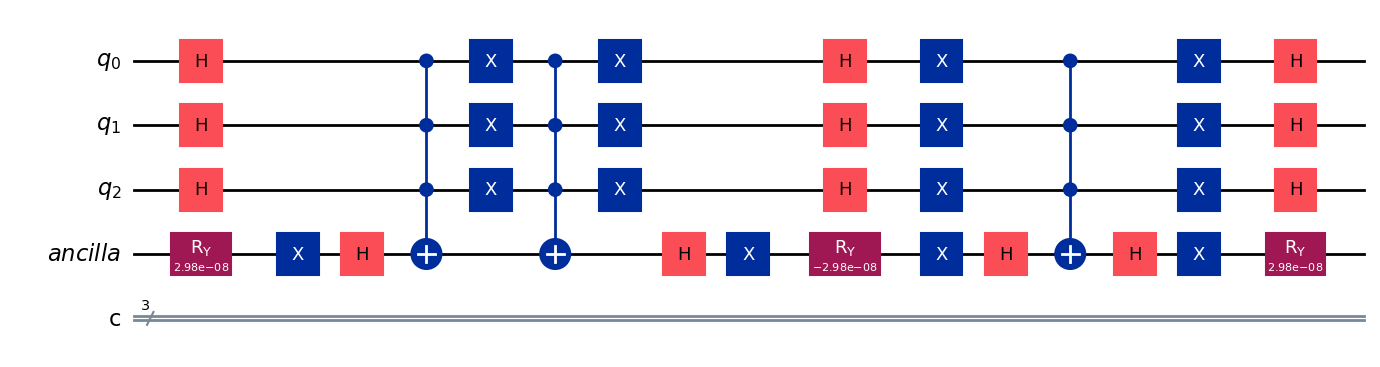

{'111': 509, '000': 491}


In [23]:
n = 3
targets = ['111', '000']
det_Grover(n, targets)